# Part 3 — Mitigation

## Rationale

Part 2 revealed three systematic failure modes (UNANSWERABLE as positive class):

| Failure mode | Evidence |
|---|---|
| **Over-trust bias** | All models hover at ~52–56 % accuracy — they rarely predict UNANSWERABLE |
| **Element blindness** | `element` corruptions → 0 % recall on both Gemma models |
| **Layout blindness** | `layout` corruptions → 9 % recall on Gemma-4b, 36 % on Gemma-12b |

Root cause: the baseline prompt forces a **single-word output** with no opportunity to reason about whether the referenced entity, element, or position actually exists.

**Three in-context learning strategies** are tested on all Part 2 models:

| # | Strategy | Mechanism | Primary target |
|---|---|---|---|
| 1 | **Chain-of-Thought (CoT)** | 3-step reasoning prompt before final label | Over-trust bias |
| 2 | **Few-Shot + CoT** | 4 labeled examples (one per corruption type + one ANSWERABLE) + CoT | Element & layout blindness |
| 3 | **Knowledge Injection** | Structured entity/element/layout checklist | All failure modes (lightweight) |

Each strategy is applied to all three models from Part 2. Per-model best strategy is identified by F1 on UNANSWERABLE and compared against the baseline.


In [1]:
CONFIG = {
    'benchmark_results_path': 'data/benchmark_results.json',
    'mitigation_results_path': 'data/mitigation_results.json',
    'figures_dir': 'data/figures',
    'seed': 42,
}

In [2]:
import gc
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from tqdm import tqdm
import torch
from PIL import Image
from transformers import AutoProcessor

Image.MAX_IMAGE_PIXELS = None

try:
    from transformers import AutoModelForImageTextToText
    _ModelClass = AutoModelForImageTextToText
except ImportError:
    from transformers import AutoModelForCausalLM
    _ModelClass = AutoModelForCausalLM

Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {p.name}  {p.total_memory / 1e9:.1f} GB")

/davinci-1/home/abuonfiglio/MasterPoliTO/GenAI/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
  GPU 0: NVIDIA A100-SXM4-40GB  42.4 GB
  GPU 1: NVIDIA A100-SXM4-40GB  42.4 GB
  GPU 2: NVIDIA A100-SXM4-40GB  42.4 GB
  GPU 3: NVIDIA A100-SXM4-40GB  42.4 GB


In [3]:
with open(CONFIG['benchmark_results_path']) as f:
    bench = json.load(f)

eval_samples        = bench['eval_samples']
ground_truth        = [s['label'] for s in eval_samples]
baseline_predictions = bench['predictions']   # {model_name: [pred, ...]}
model_names         = list(baseline_predictions.keys())

print(f"Eval set: {len(eval_samples)} samples")
print(f"  ANSWERABLE   : {ground_truth.count('ANSWERABLE')}")
print(f"  UNANSWERABLE : {ground_truth.count('UNANSWERABLE')}")
print(f"Models from Part 2: {[m.split('/')[-1] for m in model_names]}")

Eval set: 118 samples
  ANSWERABLE   : 59
  UNANSWERABLE : 59
Models from Part 2: ['llava-v1.6-mistral-7b-hf', 'gemma-3-4b-it', 'gemma-3-12b-it']


## Mitigation Strategies

### Design principles

- **CoT** adds a 3-step reasoning template: *what* is referenced → *is it present* → *final verdict*. This forces the model to check element/entity/position existence before committing to an answer.
- **Few-Shot + CoT** augments CoT with 4 in-context examples — one per corruption type plus one ANSWERABLE case. The examples are text-only (no extra images) to stay within the single-image prompt budget. Each example demonstrates the step-by-step verification chain.
- **Knowledge Injection** provides an explicit checklist (entity / element / layout) without requesting free-form reasoning. It is the lightest intervention (same `max_new_tokens=20` as the baseline) and directly names the three failure axes identified in Part 2.


In [4]:
# ── Prompt 1: Chain-of-Thought ────────────────────────────────────────────────
COT_PROMPT = '\n'.join([
    'Look at this document image carefully.',
    '',
    'Question: {question}',
    '',
    'Think step by step before answering:',
    '1. What specific entity (name, value, date), document element (table, figure,'
    ' chart, list), or spatial position (top/bottom/left/right) does the question reference?',
    '2. Examine the document: is that entity, element, or position clearly present and visible?',
    '3. Can the question be fully answered from the visible content?',
    '',
    'On the last line of your response, write exactly one word: ANSWERABLE or UNANSWERABLE',
])

# ── Prompt 2: Few-Shot + CoT ──────────────────────────────────────────────────
FEW_SHOT_COT_PROMPT = '\n'.join([
    'You are an expert at judging whether a question can be answered from a document image.',
    '',
    'Study these reference examples:',
    '',
    'EXAMPLE 1 - NLP entity corruption (UNANSWERABLE):',
    'Question: What was the unemployment rate in June 2019?',
    'Step 1: References a specific date entity (June 2019) and a statistic.',
    'Step 2: The document shows employment data, but only for 2022-2023; 2019 is absent.',
    'Step 3: The referenced entity does not appear in the document.',
    'Answer: UNANSWERABLE',
    '',
    'EXAMPLE 2 - Element corruption (UNANSWERABLE):',
    'Question: What is the label on the x-axis of Figure 2?',
    'Step 1: References a document element: Figure 2 and its x-axis.',
    'Step 2: The document contains tables and text paragraphs, but no figures or charts.',
    'Step 3: The referenced element type does not exist in this document.',
    'Answer: UNANSWERABLE',
    '',
    'EXAMPLE 3 - Layout corruption (UNANSWERABLE):',
    'Question: What text appears at the bottom-left of the page?',
    'Step 1: References a spatial position: bottom-left.',
    'Step 2: The bottom-left area of the page is blank - there is no text there.',
    'Step 3: The referenced position contains no answerable content.',
    'Answer: UNANSWERABLE',
    '',
    'EXAMPLE 4 - ANSWERABLE:',
    'Question: What is the title of this document?',
    'Step 1: Asks for the document title.',
    'Step 2: A clear title is visible at the top of the page in large bold text.',
    'Step 3: The information is present and clearly readable.',
    'Answer: ANSWERABLE',
    '',
    '---',
    'Now evaluate this question for the document image provided:',
    '',
    'Question: {question}',
    '',
    'Step 1: What does the question reference? (entity/value, element type, or spatial position)',
    'Step 2: Is that reference present and visible in the document?',
    'Step 3: Can the question be answered?',
    'Answer (one word only): ANSWERABLE or UNANSWERABLE',
])

# ── Prompt 3: Knowledge Injection ─────────────────────────────────────────────
KNOWLEDGE_INJECTION_PROMPT = '\n'.join([
    'Examine this document image and determine whether the question below can be answered.',
    '',
    'Before deciding, apply this verification checklist:',
    '  [ENTITY]  If the question names a specific value, date, name, or statistic'
    ' - does it actually appear in the document?',
    '  [ELEMENT] If the question refers to a table, figure, chart, graph, or footnote'
    ' - does that element type exist in this document?',
    '  [LAYOUT]  If the question specifies a location (top, bottom, left, right,'
    ' first, last, previous, next) - is content actually present at that location?',
    '',
    'A question is UNANSWERABLE if any check above fails.',
    '',
    'Question: {question}',
    '',
    'Answer with exactly one word: ANSWERABLE or UNANSWERABLE',
])

In [5]:
STRATEGIES = {
    'cot': {
        'name': 'Chain-of-Thought',
        'description': 'Structured 3-step reasoning before the final label',
        'prompt': COT_PROMPT,
        'max_new_tokens': 256,
    },
    'few_shot_cot': {
        'name': 'Few-Shot + CoT',
        'description': '4 labeled examples (one per corruption type + one ANSWERABLE) + CoT reasoning',
        'prompt': FEW_SHOT_COT_PROMPT,
        'max_new_tokens': 350,
    },
    'knowledge_injection': {
        'name': 'Knowledge Injection',
        'description': 'Structured entity/element/layout checklist — lightweight, no CoT',
        'prompt': KNOWLEDGE_INJECTION_PROMPT,
        'max_new_tokens': 20,
    },
}

print("Strategies defined:")
for k, v in STRATEGIES.items():
    print(f"  {k:20s} max_new_tokens={v['max_new_tokens']:4d}  {v['description']}")

Strategies defined:
  cot                  max_new_tokens= 256  Structured 3-step reasoning before the final label
  few_shot_cot         max_new_tokens= 350  4 labeled examples (one per corruption type + one ANSWERABLE) + CoT reasoning
  knowledge_injection  max_new_tokens=  20  Structured entity/element/layout checklist — lightweight, no CoT


In [6]:
def parse_label(response: str) -> str:
    """Extract ANSWERABLE/UNANSWERABLE from a potentially multi-line CoT response."""
    lines = response.upper().strip().split('\n')
    # scan from the last non-empty line upward (final answer is at the bottom of CoT)
    for line in reversed(lines):
        line = line.strip()
        if not line:
            continue
        if 'UNANSWERABLE' in line:
            return 'UNANSWERABLE'
        if 'ANSWERABLE' in line:
            return 'ANSWERABLE'
    # full-response fallback (UNANSWERABLE checked first — it contains ANSWERABLE as substring)
    upper = response.upper()
    if 'UNANSWERABLE' in upper:
        return 'UNANSWERABLE'
    if 'ANSWERABLE' in upper:
        return 'ANSWERABLE'
    return 'ANSWERABLE'   # default to the model's natural over-trust bias


def load_model(model_name: str):
    from transformers import AutoModelForCausalLM
    processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
    try:
        model = _ModelClass.from_pretrained(
            model_name,
            device_map='auto',
            torch_dtype=torch.bfloat16,
            trust_remote_code=True,
        )
    except ValueError:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map='auto',
            torch_dtype=torch.bfloat16,
            trust_remote_code=True,
        )
    model.eval()
    return model, processor


def unload_model(model, processor):
    del model, processor
    gc.collect()
    torch.cuda.empty_cache()


def predict_strategy(model, processor, pil_image, question: str, strategy: dict):
    """Run one inference with the given strategy. Returns (label, raw_response)."""
    prompt_text = strategy['prompt'].format(question=question)
    messages = [{'role': 'user', 'content': [
        {'type': 'image'},
        {'type': 'text', 'text': prompt_text},
    ]}]

    apply_fn = (getattr(processor, 'apply_chat_template', None)
                or processor.tokenizer.apply_chat_template)
    text = apply_fn(messages, add_generation_prompt=True, tokenize=False)

    device = next(model.parameters()).device
    inputs = processor(text=text, images=[pil_image], return_tensors='pt').to(device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=strategy['max_new_tokens'],
            do_sample=False,
        )

    input_len = inputs['input_ids'].shape[1]
    decode_fn = getattr(processor, 'decode', None) or processor.tokenizer.decode
    response = decode_fn(out[0][input_len:], skip_special_tokens=True).strip()
    return parse_label(response), response

## Mitigation Benchmark Loop

For each model: load once, run all three strategies, unload. Predictions and raw responses are checkpointed after each model.


In [7]:
all_mitigation_preds  = {}   # model_name -> strategy_name -> [predictions]
all_raw_responses     = {}   # model_name -> strategy_name -> [raw strings]

for model_name in model_names:
    short = model_name.split('/')[-1]
    print(f"\n{'='*60}\nModel: {model_name}\n{'='*60}")

    model, processor = load_model(model_name)
    all_mitigation_preds[model_name]  = {}
    all_raw_responses[model_name]     = {}

    for strategy_name, strategy_cfg in STRATEGIES.items():
        print(f"\n  Strategy: {strategy_cfg['name']}")
        predictions, raw_responses = [], []

        for sample in tqdm(eval_samples, desc=f'{short}/{strategy_name}'):
            img  = Image.open(sample['image_path']).convert('RGB')
            pred, raw = predict_strategy(
                model, processor, img, sample['question'], strategy_cfg
            )
            predictions.append(pred)
            raw_responses.append(raw)

        all_mitigation_preds[model_name][strategy_name] = predictions
        all_raw_responses[model_name][strategy_name]    = raw_responses
        acc_quick = sum(p == g for p, g in zip(predictions, ground_truth)) / len(ground_truth)
        print(f"    quick accuracy={acc_quick:.3f}")

    unload_model(model, processor)

    # Checkpoint after each model in case of crash
    with open(CONFIG['mitigation_results_path'], 'w') as f:
        json.dump({
            'eval_samples':          eval_samples,
            'baseline_predictions':  baseline_predictions,
            'mitigation_predictions': all_mitigation_preds,
        }, f, indent=2)
    print(f"  Checkpoint saved → {CONFIG['mitigation_results_path']}")


Model: llava-hf/llava-v1.6-mistral-7b-hf


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 687/687 [00:34<00:00, 20.17it/s] 
/davinci-1/home/abuonfiglio/MasterPoliTO/GenAI/.venv/lib/python3.10/site-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['model.image_newline']
  warnings.warn(



  Strategy: Chain-of-Thought


llava-v1.6-mistral-7b-hf/cot: 100%|██████████| 118/118 [00:56<00:00,  2.09it/s]


    quick accuracy=0.525

  Strategy: Few-Shot + CoT


...

    quick accuracy=0.525

  Strategy: Few-Shot + CoT


gemma-3-12b-it/few_shot_cot: 100%|██████████| 118/118 [05:48<00:00,  2.95s/it]


    quick accuracy=0.517

  Strategy: Knowledge Injection


gemma-3-12b-it/knowledge_injection: 100%|██████████| 118/118 [00:56<00:00,  2.07it/s]


    quick accuracy=0.542
  Checkpoint saved → data/mitigation_results.json


In [8]:
# ── Optional: reload from checkpoint to re-run only the analysis cells ─────────
# with open(CONFIG['mitigation_results_path']) as f:
#     saved = json.load(f)
# eval_samples          = saved['eval_samples']
# ground_truth          = [s['label'] for s in eval_samples]
# baseline_predictions  = saved['baseline_predictions']
# all_mitigation_preds  = saved['mitigation_predictions']
# model_names           = list(baseline_predictions.keys())

## Results Analysis


In [9]:
def compute_metrics(y_true, y_pred, model_short, condition):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=['UNANSWERABLE'], average='binary', pos_label='UNANSWERABLE',
        zero_division=0,
    )
    return {'model': model_short, 'condition': condition,
            'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

rows = []
for model_name in model_names:
    short = model_name.split('/')[-1]
    rows.append(compute_metrics(ground_truth, baseline_predictions[model_name], short, 'Baseline'))
    for strategy_name, cfg in STRATEGIES.items():
        preds = all_mitigation_preds[model_name][strategy_name]
        rows.append(compute_metrics(ground_truth, preds, short, cfg['name']))

df = pd.DataFrame(rows)
df_pivot_f1 = df.pivot(index='condition', columns='model', values='f1').round(3)
df_pivot_acc = df.pivot(index='condition', columns='model', values='accuracy').round(3)

print("=== F1 (UNANSWERABLE as positive class) ===")
print(df_pivot_f1.to_string())
print()
print("=== Accuracy ===")
print(df_pivot_acc.to_string())

=== F1 (UNANSWERABLE as positive class) ===
model                gemma-3-12b-it  gemma-3-4b-it  llava-v1.6-mistral-7b-hf
condition                                                                   
Baseline                      0.594          0.534                     0.594
Chain-of-Thought              0.317          0.000                     0.541
Few-Shot + CoT                0.424          0.634                     0.200
Knowledge Injection           0.658          0.562                     0.588

=== Accuracy ===
model                gemma-3-12b-it  gemma-3-4b-it  llava-v1.6-mistral-7b-hf
condition                                                                   
Baseline                      0.525          0.542                     0.559
Chain-of-Thought              0.525          0.492                     0.525
Few-Shot + CoT                0.517          0.551                     0.525
Knowledge Injection           0.542          0.525                     0.585


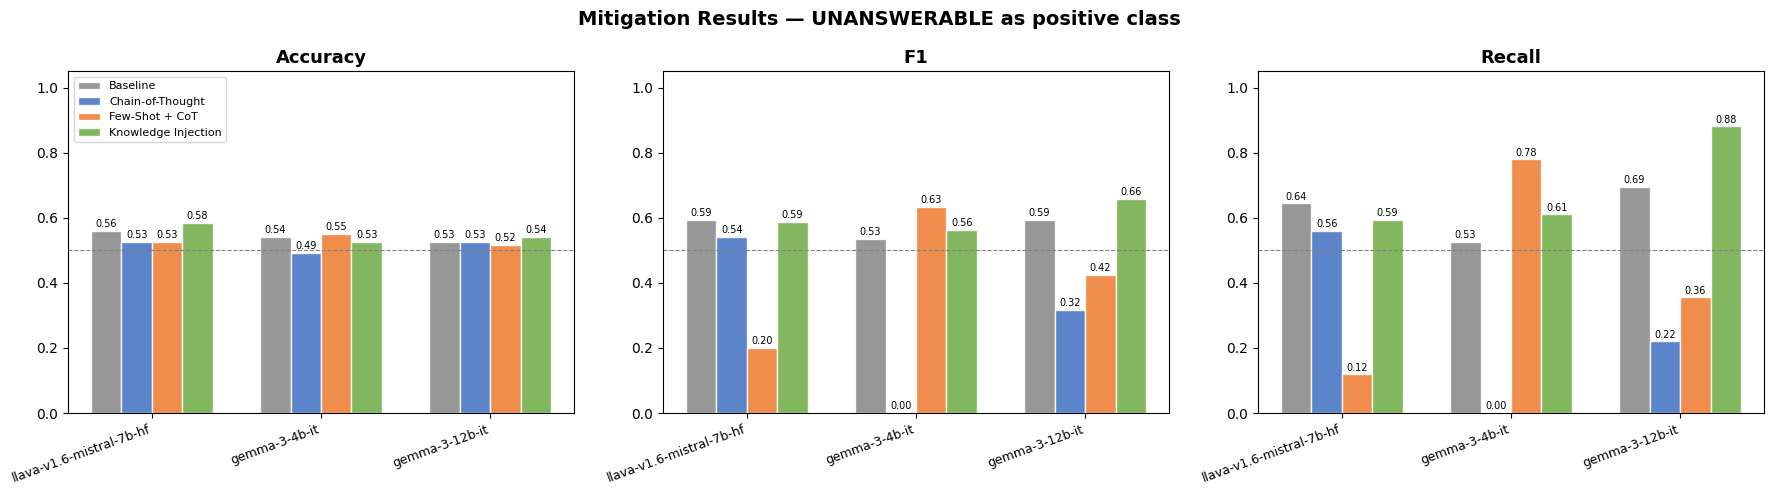

Saved → data/figures/mitigation_comparison.png


In [10]:
conditions = ['Baseline'] + [cfg['name'] for cfg in STRATEGIES.values()]
model_shorts = [m.split('/')[-1] for m in model_names]
metrics_to_plot = ['accuracy', 'f1', 'recall']
colors = ['#888888', '#4472C4', '#ED7D31', '#70AD47']

x = np.arange(len(model_shorts))
n_cond = len(conditions)
width = 0.18

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, metrics_to_plot):
    for k, (cond, color) in enumerate(zip(conditions, colors)):
        vals = [df[(df['condition'] == cond) & (df['model'] == s)][metric].values[0]
                for s in model_shorts]
        offset = (k - (n_cond - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=cond, color=color, alpha=0.87, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(metric.capitalize(), fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_shorts, rotation=20, ha='right', fontsize=9)
    if ax is axes[0]:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Mitigation Results — UNANSWERABLE as positive class', fontsize=14, fontweight='bold')
plt.tight_layout()
out = Path(CONFIG['figures_dir']) / 'mitigation_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out}")

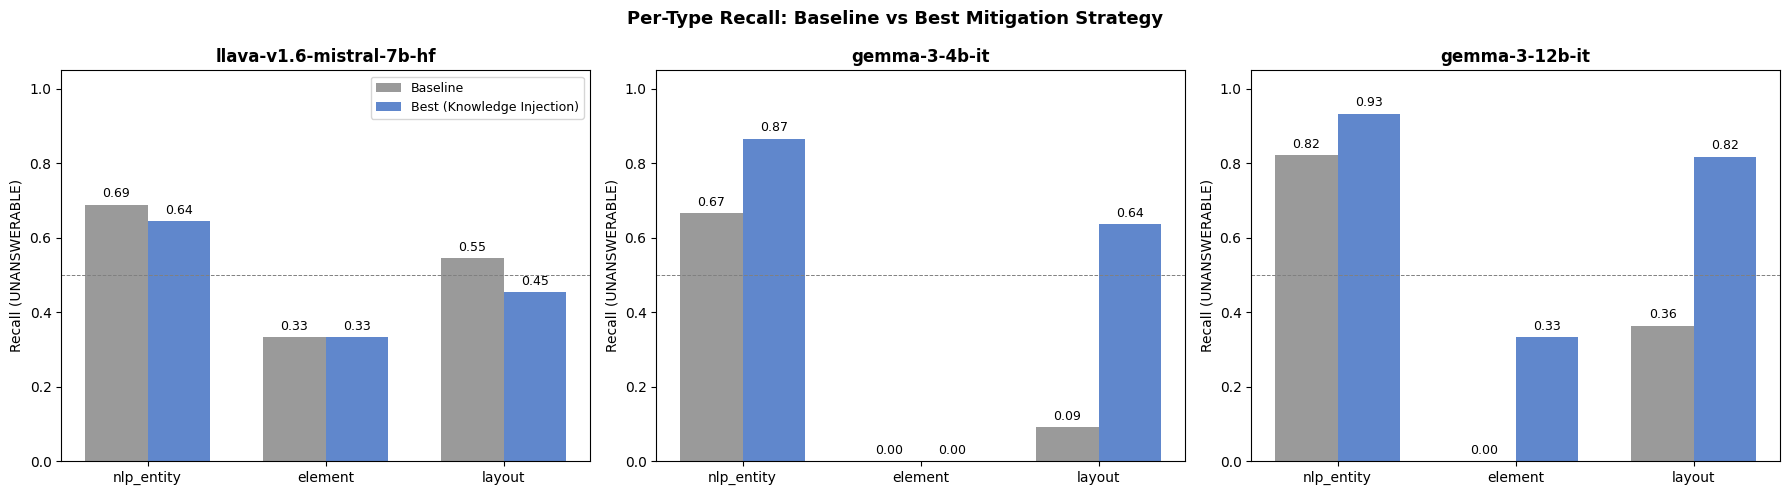

Saved → data/figures/mitigation_per_type_recall.png


In [11]:
ctypes = ['nlp_entity', 'element', 'layout']

# For each model: identify best strategy by F1
best_strategy_per_model = {}
for short in model_shorts:
    best_name, best_f1 = 'Baseline', -1.0
    for strategy_name, cfg in STRATEGIES.items():
        row = df[(df['condition'] == cfg['name']) & (df['model'] == short)]
        if not row.empty and row['f1'].values[0] > best_f1:
            best_f1 = row['f1'].values[0]
            best_name = strategy_name
    best_strategy_per_model[short] = best_name


def per_type_recall(predictions, ctype):
    idxs = [i for i, s in enumerate(eval_samples)
            if s['corruption_type'] == ctype and s['label'] == 'UNANSWERABLE']
    if not idxs:
        return 0.0
    return sum(predictions[i] == 'UNANSWERABLE' for i in idxs) / len(idxs)


fig, axes = plt.subplots(1, len(model_shorts), figsize=(6 * len(model_shorts), 5))
if len(model_shorts) == 1:
    axes = [axes]

for ax, model_name in zip(axes, model_names):
    short = model_name.split('/')[-1]
    best  = best_strategy_per_model[short]
    best_label = STRATEGIES[best]['name']

    base_r = [per_type_recall(baseline_predictions[model_name], ct) for ct in ctypes]
    best_r = [per_type_recall(all_mitigation_preds[model_name][best], ct) for ct in ctypes]

    xpos = np.arange(len(ctypes))
    w = 0.35
    ax.bar(xpos - w / 2, base_r, w, label='Baseline', color='#888888', alpha=0.85)
    ax.bar(xpos + w / 2, best_r, w, label=f'Best ({best_label})', color='#4472C4', alpha=0.85)
    ax.set_title(short, fontsize=12, fontweight='bold')
    ax.set_xticks(xpos)
    ax.set_xticklabels(ctypes, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7)
    ax.set_ylabel('Recall (UNANSWERABLE)')
    for xi, (b, m) in enumerate(zip(base_r, best_r)):
        ax.text(xi - w / 2, b + 0.02, f'{b:.2f}', ha='center', fontsize=9)
        ax.text(xi + w / 2, m + 0.02, f'{m:.2f}', ha='center', fontsize=9)
    if ax is axes[0]:
        ax.legend(fontsize=9)

plt.suptitle('Per-Type Recall: Baseline vs Best Mitigation Strategy', fontsize=13, fontweight='bold')
plt.tight_layout()
out = Path(CONFIG['figures_dir']) / 'mitigation_per_type_recall.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out}")

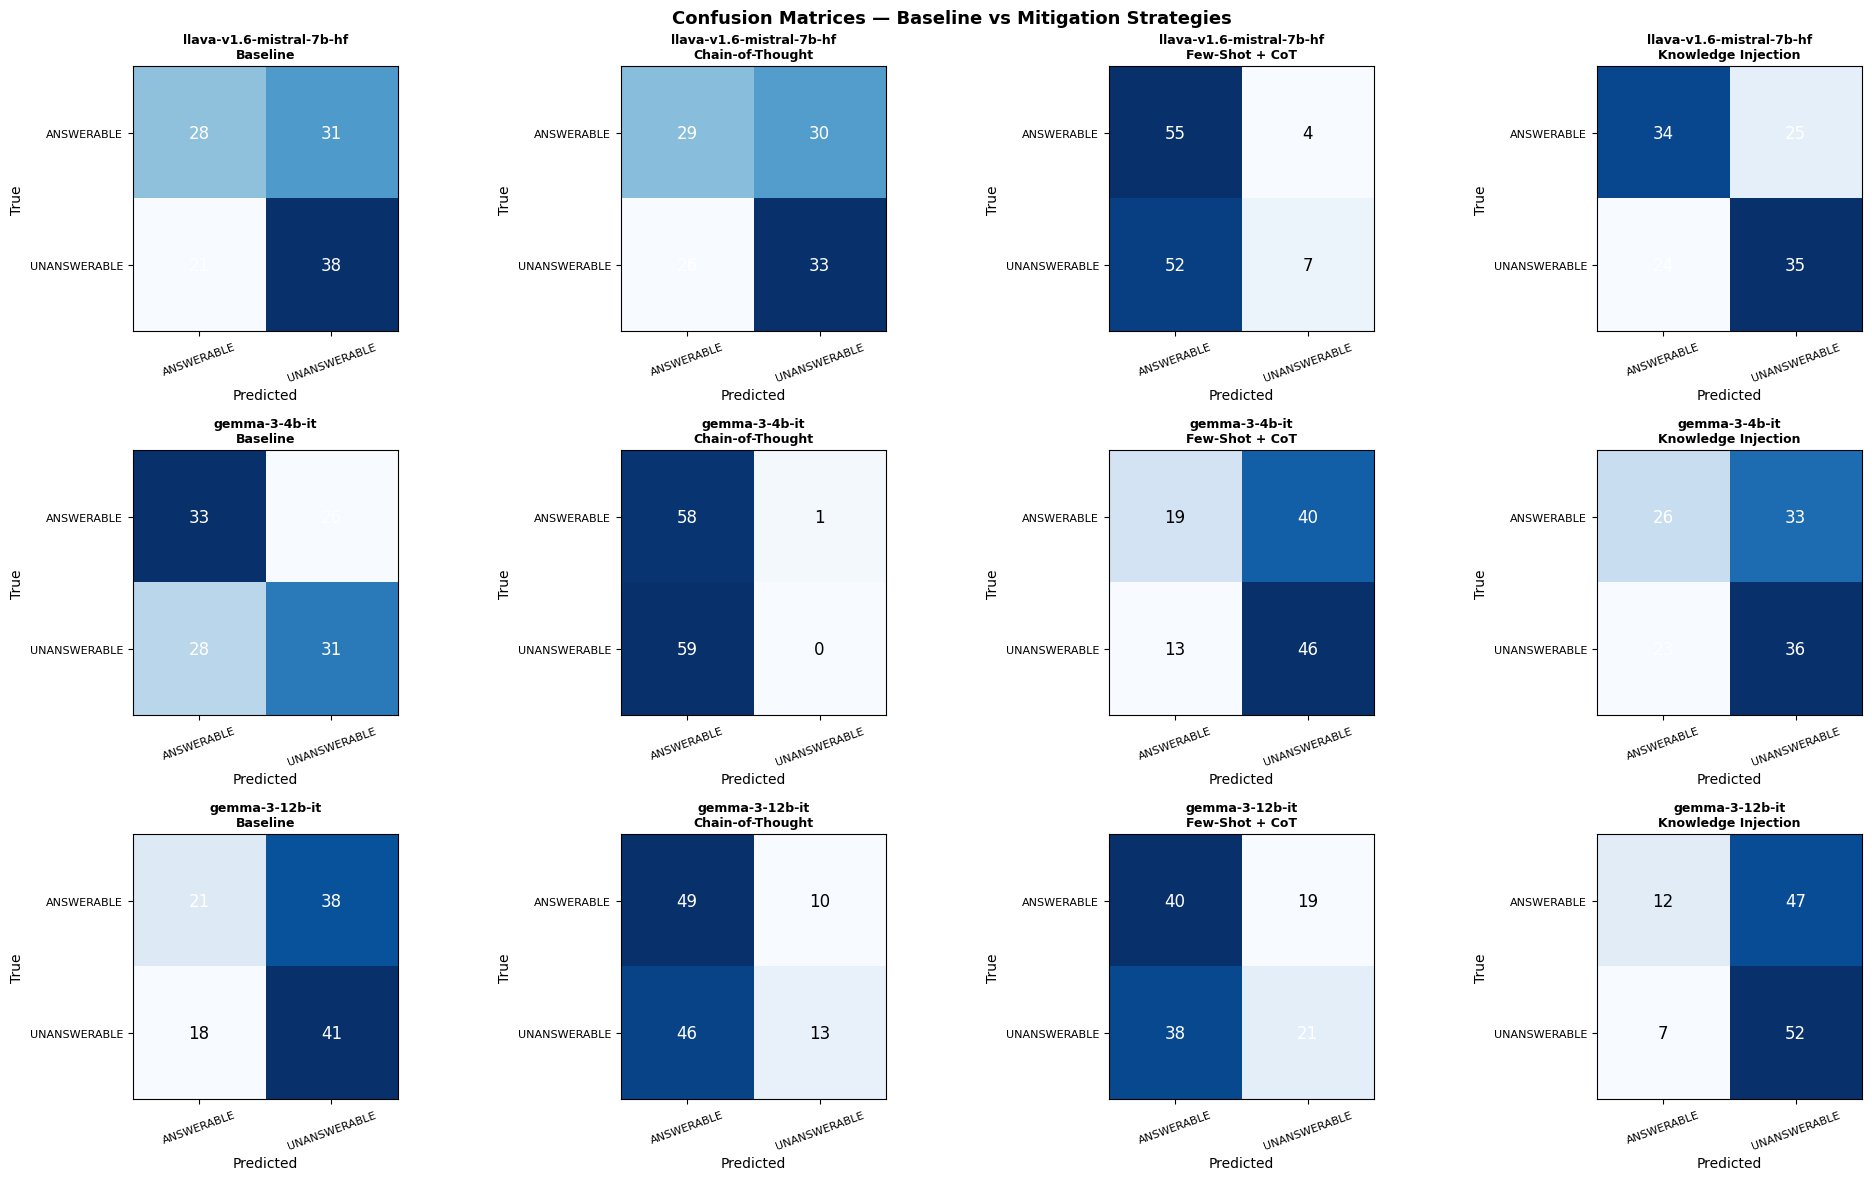

Saved → data/figures/mitigation_confusion_matrices.png


In [12]:
labels = ['ANSWERABLE', 'UNANSWERABLE']
fig, axes = plt.subplots(len(model_shorts), len(STRATEGIES) + 1,
                         figsize=(5 * (len(STRATEGIES) + 1), 4 * len(model_shorts)))
if len(model_shorts) == 1:
    axes = [axes]

for row_axes, model_name in zip(axes, model_names):
    short = model_name.split('/')[-1]
    all_preds = {'Baseline': baseline_predictions[model_name]}
    all_preds.update({cfg['name']: all_mitigation_preds[model_name][sn]
                      for sn, cfg in STRATEGIES.items()})
    for ax, (cond_name, preds) in zip(row_axes, all_preds.items()):
        cm = confusion_matrix(ground_truth, preds, labels=labels)
        im = ax.imshow(cm, cmap='Blues')
        ax.set_xticks([0, 1]); ax.set_xticklabels(labels, rotation=20, fontsize=8)
        ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{short}\n{cond_name}', fontsize=9, fontweight='bold')
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12,
                        color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.suptitle('Confusion Matrices — Baseline vs Mitigation Strategies', fontsize=13, fontweight='bold')
plt.tight_layout()
out = Path(CONFIG['figures_dir']) / 'mitigation_confusion_matrices.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out}")

## Conclusions

*(Fill in after running the cells above.)*

### Template

**Overall gains**: compare accuracy/F1/recall for each strategy vs baseline across models.

**Per-type analysis**: which strategy most improves `element` recall? `layout` recall?

**Trade-offs**:
- CoT increases context length and latency (256 max_new_tokens) but requires no examples.
- Few-Shot + CoT is the heaviest prompt (350 max_new_tokens) — check whether the gains justify the cost.
- Knowledge Injection is zero-cost in tokens — if it achieves comparable gains, it is the preferred strategy.

**Model scale effect**: does Gemma-12b benefit more from CoT than Gemma-4b? (Larger models have better instruction-following, so CoT should help more.)

**Remaining gap**: even with mitigation, which corruption type remains hardest and why?
